<a href="https://colab.research.google.com/github/Bkishorek/Drug-Side-Effects-and-Medical-Condition-Data-Analysis-/blob/main/Drug_Side_Effects__and_Medical_condition_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drug side effects and Medical conditions EDA

In [1]:
#Importing python libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing the file
df =pd.read_csv("/content/drugs_side_effects-and-medical-conditions.csv")
df.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [3]:
#rows and columns, column names
print(df.shape)
print(df.columns)


(2931, 17)
Index(['drug_name', 'medical_condition', 'side_effects', 'generic_name',
       'drug_classes', 'brand_names', 'activity', 'rx_otc',
       'pregnancy_category', 'csa', 'alcohol', 'related_drugs',
       'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link',
       'medical_condition_url'],
      dtype='object')


In [4]:
#checking non- null values data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

In [5]:
# removing unnecessary columns
df.drop(columns = ['brand_names'], inplace = True)

In [6]:
#checking duplicates
duplicate_rows = df[df.duplicated()]
duplicate_count = duplicate_rows.shape[0]
print('Duplicate count:',duplicate_count)
duplicate_rows

Duplicate count: 0


,drug_name,medical_condition,side_effects,generic_name,drug_classes,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url


In [7]:
#checking for missing values
df.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,124
generic_name,43
drug_classes,82
activity,0
rx_otc,1
pregnancy_category,229
csa,0
alcohol,1554


In [8]:
#Dealing with missing values
#Filling alcohol

df['alcohol'] = df['alcohol'].replace(pd.NA, '0')
df['alcohol'] = df['alcohol'].replace({'X': 1})

#Filling side effects

df['side_effects'] = df['side_effects'].fillna('Unknown')

#filling related_drugs
df['related_drugs'] = df['related_drugs'].fillna('Unknown')

#Filling rating
df['rating'] = df['rating'].fillna(0)

#filling no_of_reviews
df['no_of_reviews'] = df['no_of_reviews'].fillna(0)

#filling generic nmae
df['generic_name'] = df['generic_name'].fillna('Unknown')

#filling drug_classes
df['drug_classes'] = df['drug_classes'].fillna('Unknown')

#filling rx_otc
df['rx_otc'] = df['rx_otc'].fillna('Unknown')

#filling pregnancy_category
df['pregnancy_category'] = df['pregnancy_category'].fillna('Unknown')


In [9]:
#checking missing values again
df.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,0
generic_name,0
drug_classes,0
activity,0
rx_otc,0
pregnancy_category,0
csa,0
alcohol,0


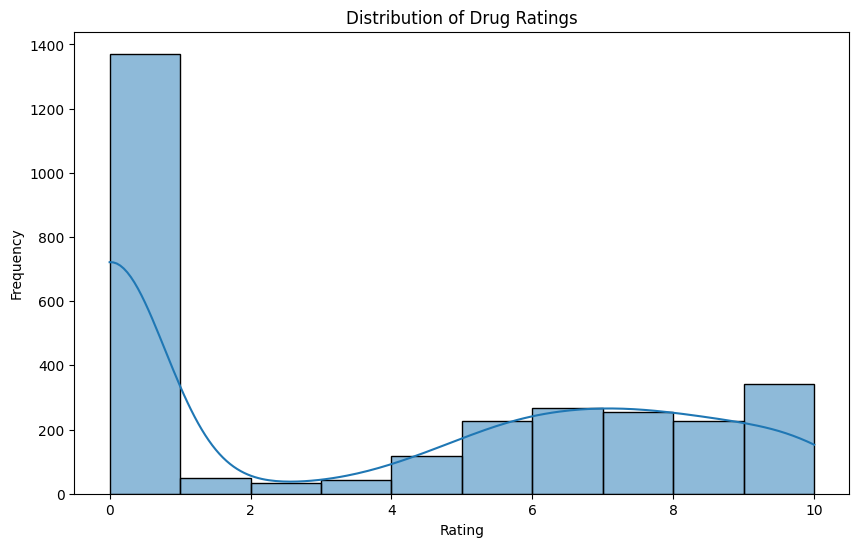

In [10]:
#visualization
#Distribution of drug ratings
plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Drug Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [11]:
#Most common medical condition (top 10)
medical_condition_counts= df['medical_condition'].value_counts().head(10)

medical_condition_counts.sort_values(ascending=False)



,count
medical_condition,
Pain,264
Colds & Flu,245
Acne,238
Hypertension,177
Osteoarthritis,129
Hayfever,124
Eczema,122
AIDS/HIV,109
Diabetes (Type 2),104


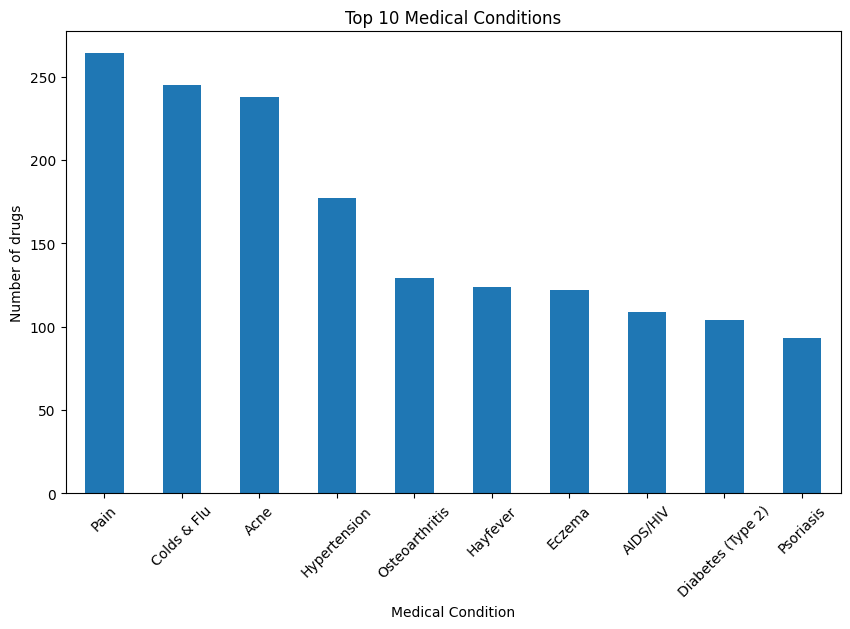

In [12]:
#visualizing top 10 medical condition
plt.figure(figsize=(10,6))
df['medical_condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of drugs')

plt.xticks(rotation=45)
plt.show()


In [13]:
#Analysing and visualising side_effects
#Many side effects are written in one cell, hence splitting and arranging it in order.
import re

def extract_side_effects(text):
      return [effect.strip()for effect in text.split(';')]

side_effects = df['side_effects'].apply (extract_side_effects)

side_effects




,side_effects
0,"[(hives, difficult breathing, swelling in your..."
1,"[hives, difficulty breathing, swelling of your..."
2,"[skin rash, fever, swollen glands, flu-like sy..."
3,"[problems with your vision or hearing, muscle ..."
4,"[hives, difficult breathing, swelling of your ..."
...,...
2926,"[hives, difficulty breathing, swelling of your..."
2927,"[hives, difficult breathing, swelling of your ..."
2928,[Unknown]
2929,"[Imcivree may cause serious side effects, incl..."


In [14]:
side_effects = side_effects.explode()
side_effects

,side_effects
0,"(hives, difficult breathing, swelling in your ..."
0,"throat irritation, trouble swallowing"
0,"chest pain, irregular heart rhythm, feeling sh..."
0,little or no urination
0,"low white blood cell counts - fever, chills, s..."
...,...
2930,"swelling of your face, lips, tongue, or throat..."
2930,skin darkening
2930,headache
2930,erection without any sexual activity in males


In [15]:
# Side effect count based on the number of times of appearance.
side_effects_counts = side_effects.value_counts().head(10)
side_effects_counts


,count
side_effects,
hives,1788
difficult breathing,1130
difficulty breathing,450
itching,275
"a light-headed feeling, like you might pass out",272
unusual hoarseness,266
"trouble breathing, swallowing, or talking",266
tightness in the chest or throat,266
wheezing,266


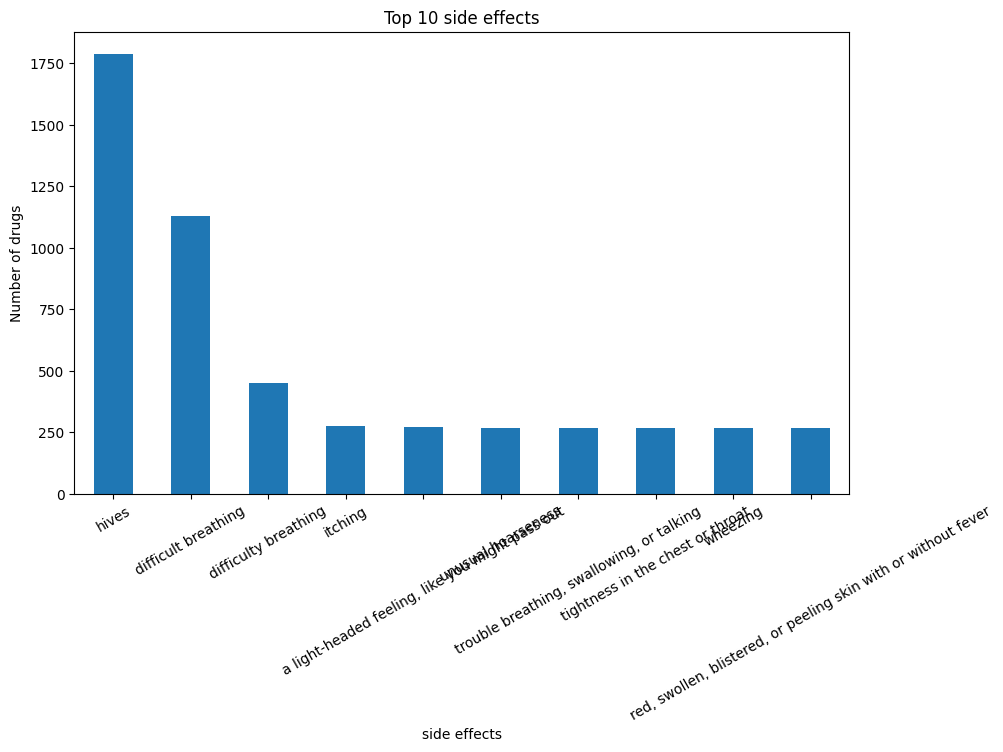

In [16]:
plt.figure(figsize=(10,6))
side_effects_counts = side_effects.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 side effects')
plt.xlabel('side effects')
plt.ylabel('Number of drugs')

plt.xticks(rotation=30)
plt.show()

In [17]:
#extracting side_effects and drug_classes to explodes sideeffects into separate column
#creating date frame ofside effects and drug_classes
df_new = df[['drug_classes','side_effects']].copy()


In [18]:
# Split side effects (both comma and semicolon)
df_new['side_effects'] = df_new['side_effects'].str.split(';')

# Explode into one side effect per row
df_new = df_new.explode('side_effects')

# Remove leading/trailing spaces
df_new['side_effects'] = df_new['side_effects'].str.strip()

# Remove empty values
df_new = df_new[df_new['side_effects'] != '']

# finding rare sideeffects spread over multiple drug_classes (by considering rare side effects count 10)
rare_analysis = (
    df_new.groupby('side_effects')
    .agg(
        count=('side_effects', 'size'),
        drug_class_count=('drug_classes', 'nunique')
    )
    .reset_index()
)

# Keeping only rare side effects (occurring times)
rare_analysis = rare_analysis[rare_analysis['count'] == 10]

# Keeping only those present in more than 4 drug class
rare_analysis = rare_analysis[rare_analysis['drug_class_count'] > 4]

print('Total rare side effects:',rare_analysis.count())

# Display results
print(rare_analysis.sort_values('drug_class_count', ascending=False).head(20))


Total rare side effects: side_effects        11
count               11
drug_class_count    11
dtype: int64
                                           side_effects  count  \
2172                                      itching, rash     10   
2683                       nausea , vomiting , diarrhea     10   
2483  low red blood cells (anemia)--pale skin, unusu...     10   
8240                                      upset stomach     10   
2737                              nausea, upset stomach     10   
2713                               nausea, constipation     10   
1257  coughing up blood or vomit that looks like cof...     10   
1935  heart problems--swelling, rapid weight gain, f...     10   
2480  low red blood cells (anemia) - pale skin, unus...     10   
2727                               nausea, stomach pain     10   
6385                                     sleep problems     10   

      drug_class_count  
2172                 6  
2683                 6  
2483                 6  


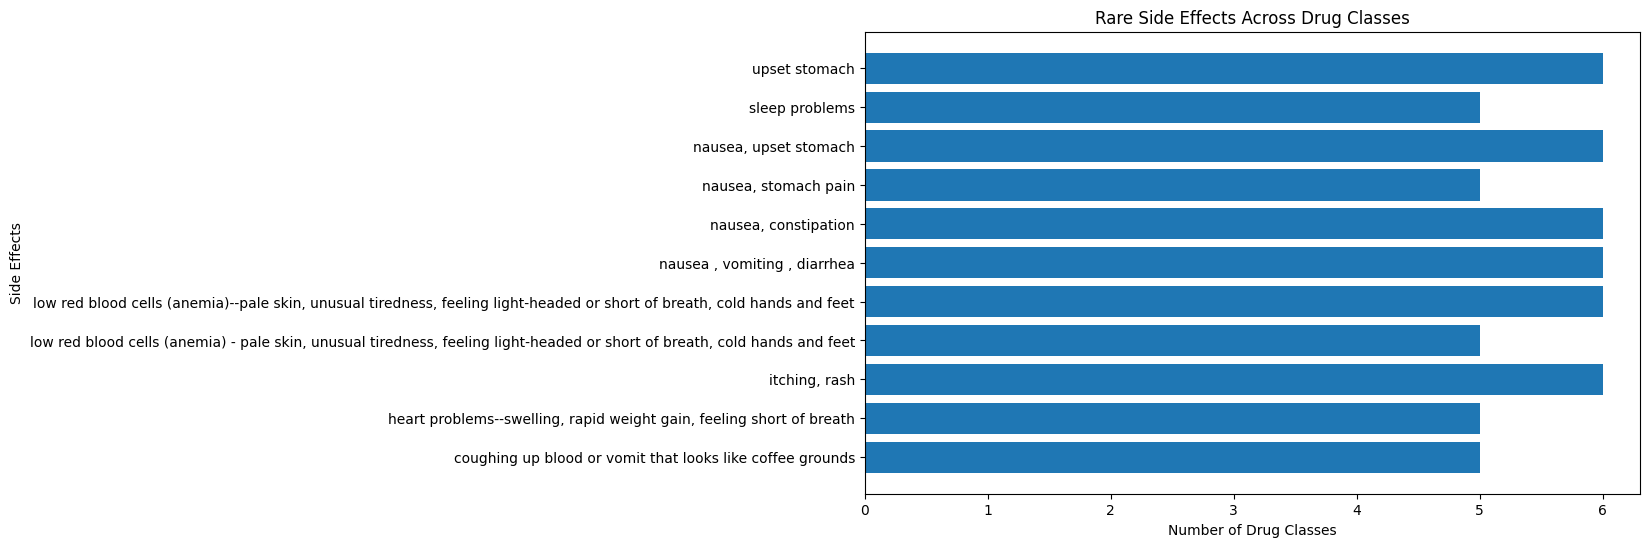

In [19]:
plt.figure(figsize=(10,6))
plt.barh(rare_analysis['side_effects'], rare_analysis['drug_class_count'])

plt.title("Rare Side Effects Across Drug Classes")
plt.xlabel("Number of Drug Classes")
plt.ylabel("Side Effects")

plt.show()

In [20]:
### relation of Drug class

In [21]:
##Extracting top 10 drug classes
top_classes = df['drug_classes'].value_counts().head(10).index
df_top = df[df['drug_classes'].isin(top_classes)]


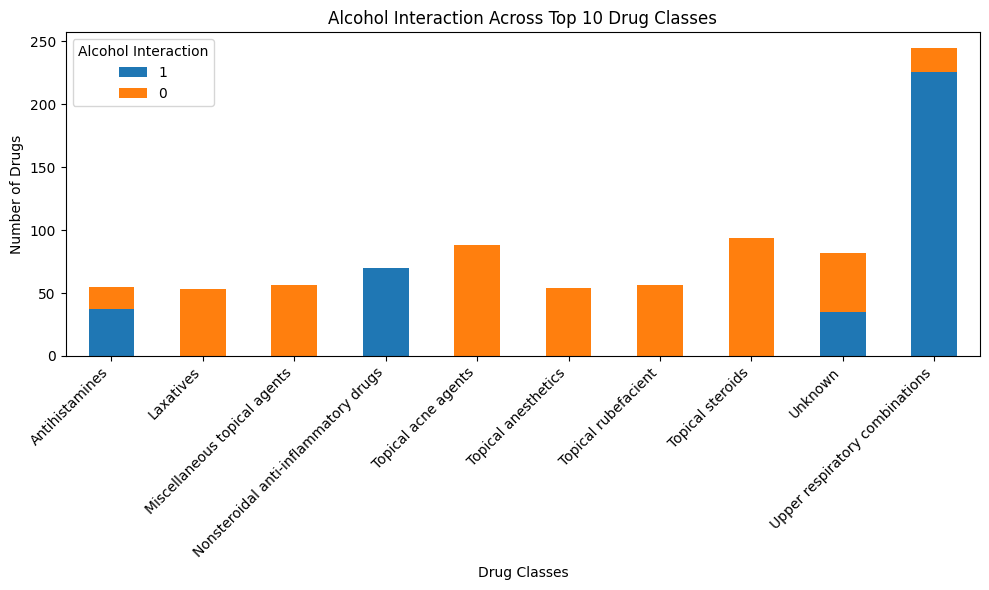

In [22]:
#Relation between Drug classes vs alcohol interaction

table =pd.crosstab(df_top['drug_classes'], df_top['alcohol'])
table.plot(kind='bar', stacked=True, figsize =(10,6))

plt.title("Alcohol Interaction Across Top 10 Drug Classes")
plt.xlabel("Drug Classes")
plt.ylabel("Number of Drugs")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Alcohol Interaction")
plt.tight_layout()

plt.show()


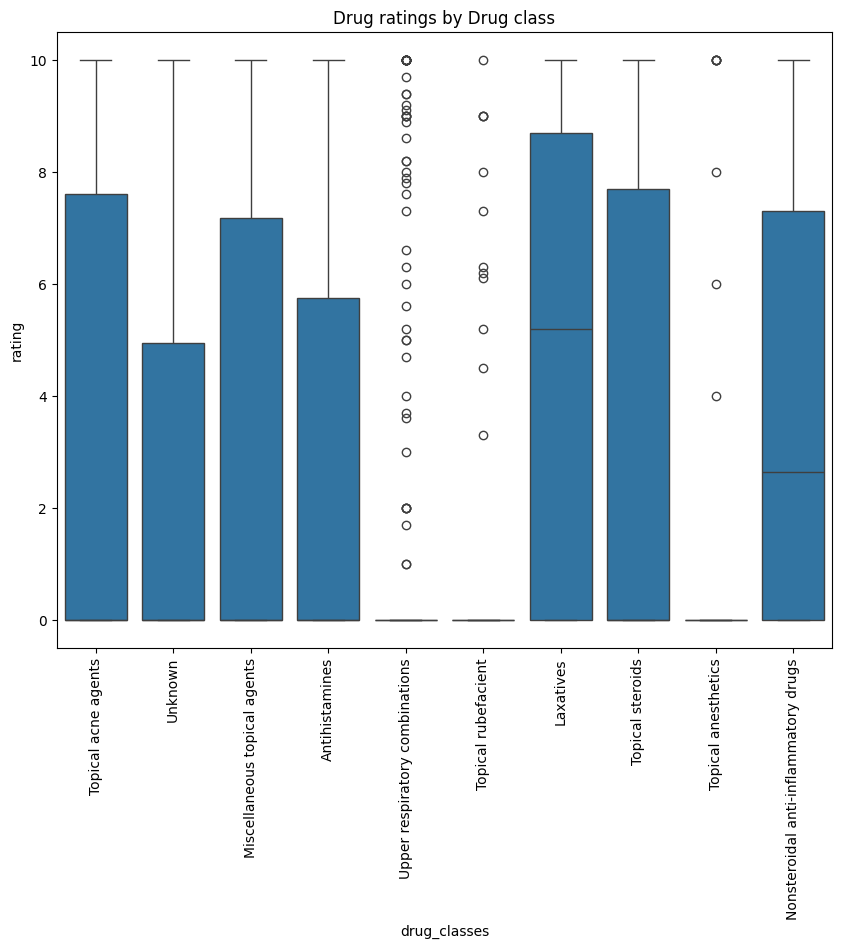

In [23]:
# visualising drug ratings by drug class
plt.figure(figsize=(10,8))
sns.boxplot(x='drug_classes', y= 'rating', data =df_top)

plt.xticks(rotation=90)
plt.title('Drug ratings by Drug class')
plt.show()


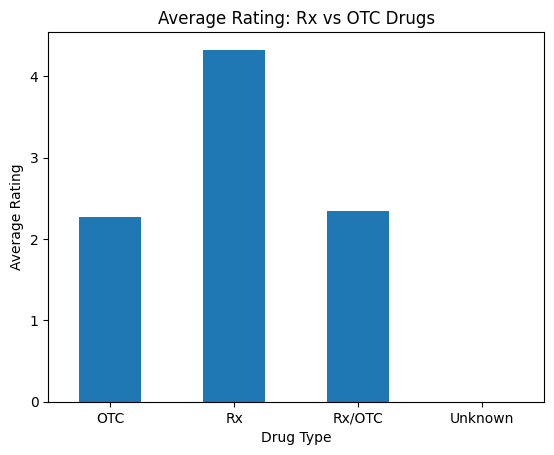

In [24]:
#Finding rating difference between rx products and otc prooducts.

Avg_rx_otc_rating = df.groupby('rx_otc')['rating'].mean()

Avg_rx_otc_rating.plot(kind='bar')

plt.title('Average Rating: Rx vs OTC Drugs')
plt.xlabel('Drug Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)

plt.show()




In [25]:
df_copy= df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



df_copy['pregnancy_category'] = le.fit_transform(df_copy['pregnancy_category'])
df_copy['rx_otc'] = le.fit_transform(df_copy['rx_otc'])
df_copy['csa'] = le.fit_transform(df_copy['csa'])



In [26]:
df_model = df_copy[[
               'rating',
               'no_of_reviews',
               'pregnancy_category',
               'rx_otc',
               'csa',
               'alcohol']]

In [27]:
#creating correlation heatmap
correl= df_model.corr()
correl

,rating,no_of_reviews,pregnancy_category,rx_otc,csa,alcohol
rating,1.000000,0.217858,0.004731,-0.057234,-0.157163,0.094445
no_of_reviews,0.217858,1.000000,0.038573,-0.040180,-0.146258,0.115464
pregnancy_category,0.004731,0.038573,1.000000,-0.138719,-0.025689,0.055809
rx_otc,-0.057234,-0.040180,-0.138719,1.000000,0.038185,0.026253
csa,-0.157163,-0.146258,-0.025689,0.038185,1.000000,-0.262187
alcohol,0.094445,0.115464,0.055809,0.026253,-0.262187,1.000000


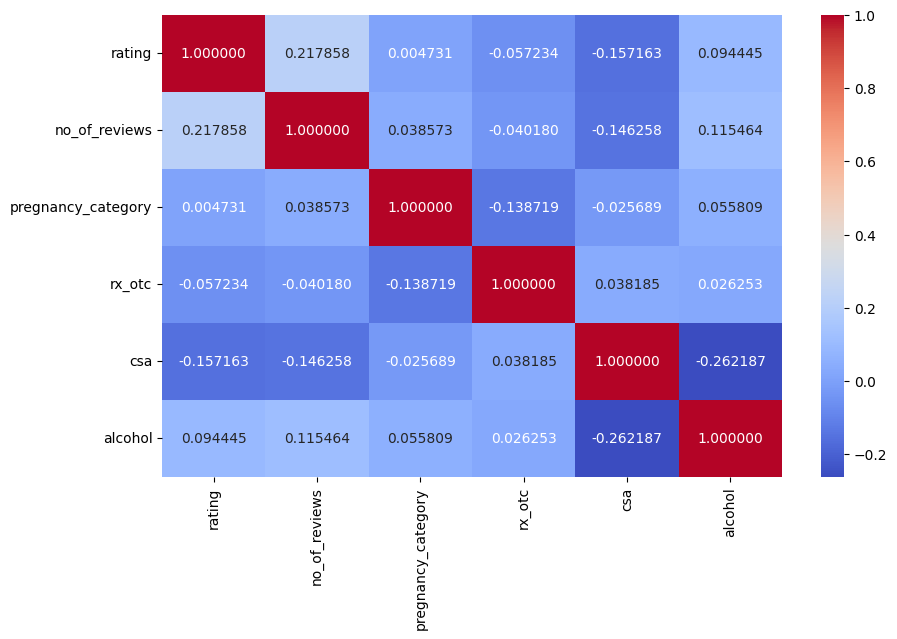

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(correl, annot=True, cmap="coolwarm", fmt ="2f")


plt.show()

By heatmap, it tells that more reviews are tend to have slightly
higher ratings.


In [29]:
#Saving cleaned file
df.to_csv('Drug_side_effects_and_medical_condition_cleaned.csv', index= False)

In [30]:
from google.colab import files
files.download('Drug_side_effects_and_medical_condition_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>